# YouNiverse: Mapping YouTube's Hidden Communities

## Project Abstract

This project aims to uncover the hidden architecture of YouTube's content landscape. Instead of relying on explicit channel categories, we build a graph based on **audience overlap**. 

The core logic is this: for each user, we find the **Top-K channels** they comment on the most. We then create edges *only* between these Top-K channels. This creates a high-signal graph of true audience affinity.

This notebook documents the end-to-end pipeline by calling scripts from our `src` directory:

1.  **Data Loading:** Ingest channel and video metadata using `src.data.load`.
2.  **Graph Construction:** Stream comments to build the Top-K co-commenter graph using `src.scripts.process_data`.
3.  **Graph Analysis:** Normalize the graph (using our new commenter counts), run community detection, and calculate metrics using `src.models.analysis`.
4.  **Results:** Analyze and visualize the resulting communities.

## 1. Setup and Imports

First, we set up our environment, adding the `src` directory to the path and importing our custom-built modules.

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import our custom modules
from src.data import data_loader 
from src.scripts import process_data as data_processor
from src.models import model_analysis as model_analyzer

print("Successfully imported src modules.")

Successfully imported src modules.


### Configuration

We set our main analysis parameters here. These will be passed to our scripts.

In [2]:
# --- Parameters ---
MIN_SUBSCRIBERS = 200_000
MIN_EDGE_WEIGHT = 3
MAX_COMMENT_ROWS = 150_000_000 

# --- New Top-K Parameters ---
TOP_K_PER_AUTHOR = 5
MIN_CHANS_FOR_PAIRS = 2
AUTHOR_FLUSH_THRESHOLD = 500_000

# --- Normalization Parameters ---
NORM_ALPHA = 0.5
NORM_BETA = 1.0
USE_ENGAGEMENT_METRIC = True # Use commenter counts

# --- File Paths (relative to project root) ---
CHANNEL_METADATA_PATH = "data/raw/df_channels_en.tsv" 
VIDEO_METADATA_PATH = "data/raw/yt_metadata_helper.feather"

EDGES_OUT_PATH = "data/processed/channel_edges.csv"
CHECKPOINT_PATH = "data/processed/edges_checkpoint.pkl"
STATE_PATH = "data/processed/state.json"
DICT_PATH = "data/processed/channel_commenter_counts.csv"

NODES_OUT_PATH = "data/processed/chan_graph_node_metrics.csv"
COMMUNITIES_OUT_PATH = "data/processed/chan_graph_community_summary.csv"
VIZ_OUT_PATH = "reports/figures/network_viz.png"

# Ensure processed/reports directories exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

print("Configuration and paths set.")

Configuration and paths set.


## 2. Data Loading and Preparation

First, we load the metadata we need to build our helper maps.
1.  **Channel Metadata:** To get subscriber counts for filtering.
2.  **Video Metadata:** To create a lookup map from `video_id` to `channel_id`.



In [3]:
# Load data using our loader script
dfChannels = pd.read_csv(CHANNEL_METADATA_PATH,sep='\t')
videoDf = data_loader.load_video_metadata(local_path=VIDEO_METADATA_PATH, columns=["display_id", "channel_id"])

# Create helper maps using our processing script
v2c_map = data_processor.build_video_to_channel_map(videoDf)
channel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)

del videoDf # Free up memory

Loading Video Metadata...
Loaded 72,924,794 video records.
Creating 72,924,794 v2c mappings...
Created channel subset map. 25,956 channels selected.


## 3. Graph Construction: Streaming Comments

This is the most computationally intensive step. We call our `generate_edges` script.

As this probably would take too long to run on a personal computer without a graphic card, we created a notebook to be ran on a cloud computing platform like Google colab in src/data/data_loader.ipynb that creates edges and channel dictionary. They should be put in EDGES_OUT_PATH and DICT_PATH.

This function will stream comments, process them using the **Top-K logic**, and save both `channel_edges.csv` and the new `channel_commenter_counts.csv`.

It is also possible to create the graph only for videos published during a specific range of time. That is also shown in src/data/dataloader.ipynb. This will allow us to show the graph progress through time.

In [4]:
v2c_map = None
'''
edges_df = data_processor.generate_edges(
    v2c_map,
    EDGES_OUT_PATH,
    CHECKPOINT_PATH,
    STATE_PATH,
    DICT_PATH,
    max_rows=MAX_COMMENT_ROWS,
    top_k_per_author=TOP_K_PER_AUTHOR,
    min_chans_for_pairs=MIN_CHANS_FOR_PAIRS,
    author_flush_threshold=AUTHOR_FLUSH_THRESHOLD
)'''
edges_df = pd.read_csv(EDGES_OUT_PATH)
print(f"\nSuccessfully loaded {len(edges_df):,} edges.")
edges_df.head()


Successfully loaded 15,962,236 edges.


,src,dst,weight
0,UCBXNpF6k2n8dsI6nBH8q4sQ,UCM2ERkgV3P1_6MAyxa51rxA,19
1,UCBXNpF6k2n8dsI6nBH8q4sQ,UCpB959t8iPrxQWj7G6n0ctQ,35
2,UCBXNpF6k2n8dsI6nBH8q4sQ,UCtwD0AlYSlAYv7eXu8UxtEg,7
3,UCM2ERkgV3P1_6MAyxa51rxA,UCpB959t8iPrxQWj7G6n0ctQ,158
4,UCM2ERkgV3P1_6MAyxa51rxA,UCtwD0AlYSlAYv7eXu8UxtEg,11


## 4. Graph Analysis Pipeline

Now we run the main analysis pipeline. Let us find communities of similar channels based on audience. 

We will normalize our graph. The problem now is that two big channels will automatically have an edge between them with a high enough weight to shadow two smaller channels with the same edge weight but which is way more representative of channel similarity proportionally to their size. 

For example, Channel 1 and Channel 2 both have 500k total commenters that we scraped from the data. The edge weight is 10k meaning 10k of these users commented both on videos from channel 1 and channel 2. Proportionally to the channel size this is not a huge value. <br/>
On the other hand we have Channel 3 and 4 which both have 10k commenters. This time the edge weight is 5k. Meaning approximately half of their audience is shared! Edge weight is then not the best indicator channel similarity <br/> <br/>
Knowing this, we normalize edge weight to get more of a "similarity score" and find more niche communities.

In [5]:

edges_filtered, channels_indexed = model_analyzer.filter_edges(
    edges_df, dfChannels, MIN_SUBSCRIBERS, MIN_EDGE_WEIGHT
)

commenter_counts = data_loader.load_commenter_counts(DICT_PATH)

edges_normalized = model_analyzer.normalize_edges(
    edges_filtered, 
    channels_indexed, 
    commenter_counts, 
    alpha=NORM_ALPHA, 
    beta=NORM_BETA, 
    use_engagement=USE_ENGAGEMENT_METRIC
)


G = model_analyzer.build_graph(edges_normalized, channels_indexed)

LCC, communities, node_df, comm_summary = model_analyzer.find_communities(
    G, nodes_out_path=NODES_OUT_PATH, comm_out_path=COMMUNITIES_OUT_PATH
)

Filtering edges: >200000 subs, >3 weight.
Filtered down to 2,476,360 edges.
Loading commenter counts from data/processed/channel_commenter_counts.csv...
Loaded 128,499 channel commenter counts.
Normalizing edge weights...
Using commenters (Top-K) (median=48) for normalization.
Building graph from normalized edges...
Graph built: 24,353 nodes, 2,476,360 edges
Finding Largest Connected Component (LCC)...
LCC:   24,353 nodes, 2,476,360 edges  (100.0% of nodes)
Detecting communities using Louvain...
Found 14 communities (modularity: 0.524)
Calculating node metrics (PageRank, Strength)...

✓ Saved node metrics and community summary.


## 5. Results and Interpretation

Our pipeline is complete. The results are saved in `data/processed/`. We can now load them for analysis.

### Result 1: Top 10 Largest Communities

This table shows the largest "galaxies" we found, sorted by the number of channels they contain.

In [6]:
print("Top 10 Largest Communities:")
print(comm_summary.head(10).to_string(index=False))

Top 10 Largest Communities:
 community  n_nodes  total_strength  avg_degree  avg_strength
         9     4216        11074472  175.491461   2626.772296
         0     3919         9126440  208.229650   2328.767543
         6     3505        16955693  289.210271   4837.572896
         2     3448        17178424  255.889791   4982.141531
        12     3264         4274216  136.672181   1309.502451
         7     2349         7038794  182.364410   2996.506599
         4     1510         3277580  187.385430   2170.582781
         8      871         2791797  170.182549   3205.277842
         5      478         1307583  124.546025   2735.529289
         3      399         1675342  236.040100   4198.852130


### Result 2: Top 10 Most Influential Channels

This table shows the top 10 channels ranked by **PageRank**. PageRank identifies channels that are connected to *other* influential channels. These are the "super-connectors" in our YouNiverse.

In [7]:
print("Top 10 Channels by PageRank:")
print(node_df.nlargest(10, "pagerank")[
    ["name_cc", "category_cc", "subscribers_cc", "community", "degree", "pagerank"]
].to_string(index=False))

Top 10 Channels by PageRank:
         name_cc          category_cc  subscribers_cc  community  degree  pagerank
       PewDiePie               Gaming       101000000          6   12529  0.009641
        T-Series                Music       112139463          9    7463  0.006680
          DanTDM               Gaming        22100000          6    6047  0.004152
   jacksepticeye               Gaming        22833014          6    6355  0.003704
     PopularMMOs               Gaming        16900000          2    5479  0.003583
       Jake Paul       People & Blogs        19600000          2    5987  0.003530
Technical Guruji Science & Technology        13979890          9    4189  0.003406
      Markiplier               Gaming        24400000          6    6391  0.003253
  The ACE Family       People & Blogs        17600000          7    5287  0.002745
Logan Paul Vlogs        Entertainment        19800000          2    5937  0.002700


### Result 3: Deep Dive into Community Profiles

We now call our analysis script to analyze the top communities. This helps us put a name and a theme to our algorithmically-defined clusters.

In [8]:
# Run the analysis script
model_analyzer.analyze_communities(LCC, node_df, communities, max_show=20)

--- Deep Dive into Top 5 Communities ---
COMMUNITY 0
Size: 3919 nodes, 177088 edges
Top category: Music (2443/3919) 
--------------------------------------------------------------------------------
Categories:
  Music                2443 (62.3%)
  Entertainment         606 (15.5%)
  People & Blogs        173 (4.4%)
  Film and Animation    140 (3.6%)
  Gaming                125 (3.2%)
--------------------------------------------------------------------------------
Top 5 Channels (by Subscribers):
         name_cc category_cc  strength  subscribers_cc
ArianaGrandeVevo       Music    120272        18712584
 TaylorSwiftVEVO       Music    101243        27200000
   KatyPerryVEVO       Music     99861        26000000
OneDirectionVEVO       Music     97778        22900000
    XXXTENTACION       Music     87035        21900000

COMMUNITY 1
Size: 92 nodes, 1313 edges
Top category: Entertainment (45/92) 
--------------------------------------------------------------------------------
Categories:

### Result 4: Network Visualization

Finally, we call our visualization script to generate and save a plot of the graph.

**Nodes** are colored by their community and sized by their strength and the legend shows us the top youtuber by community.

Generating network visualization...
Visualization subgraph: 130 nodes, 4474 edges
✓ Saved reports/figures/network_viz.png


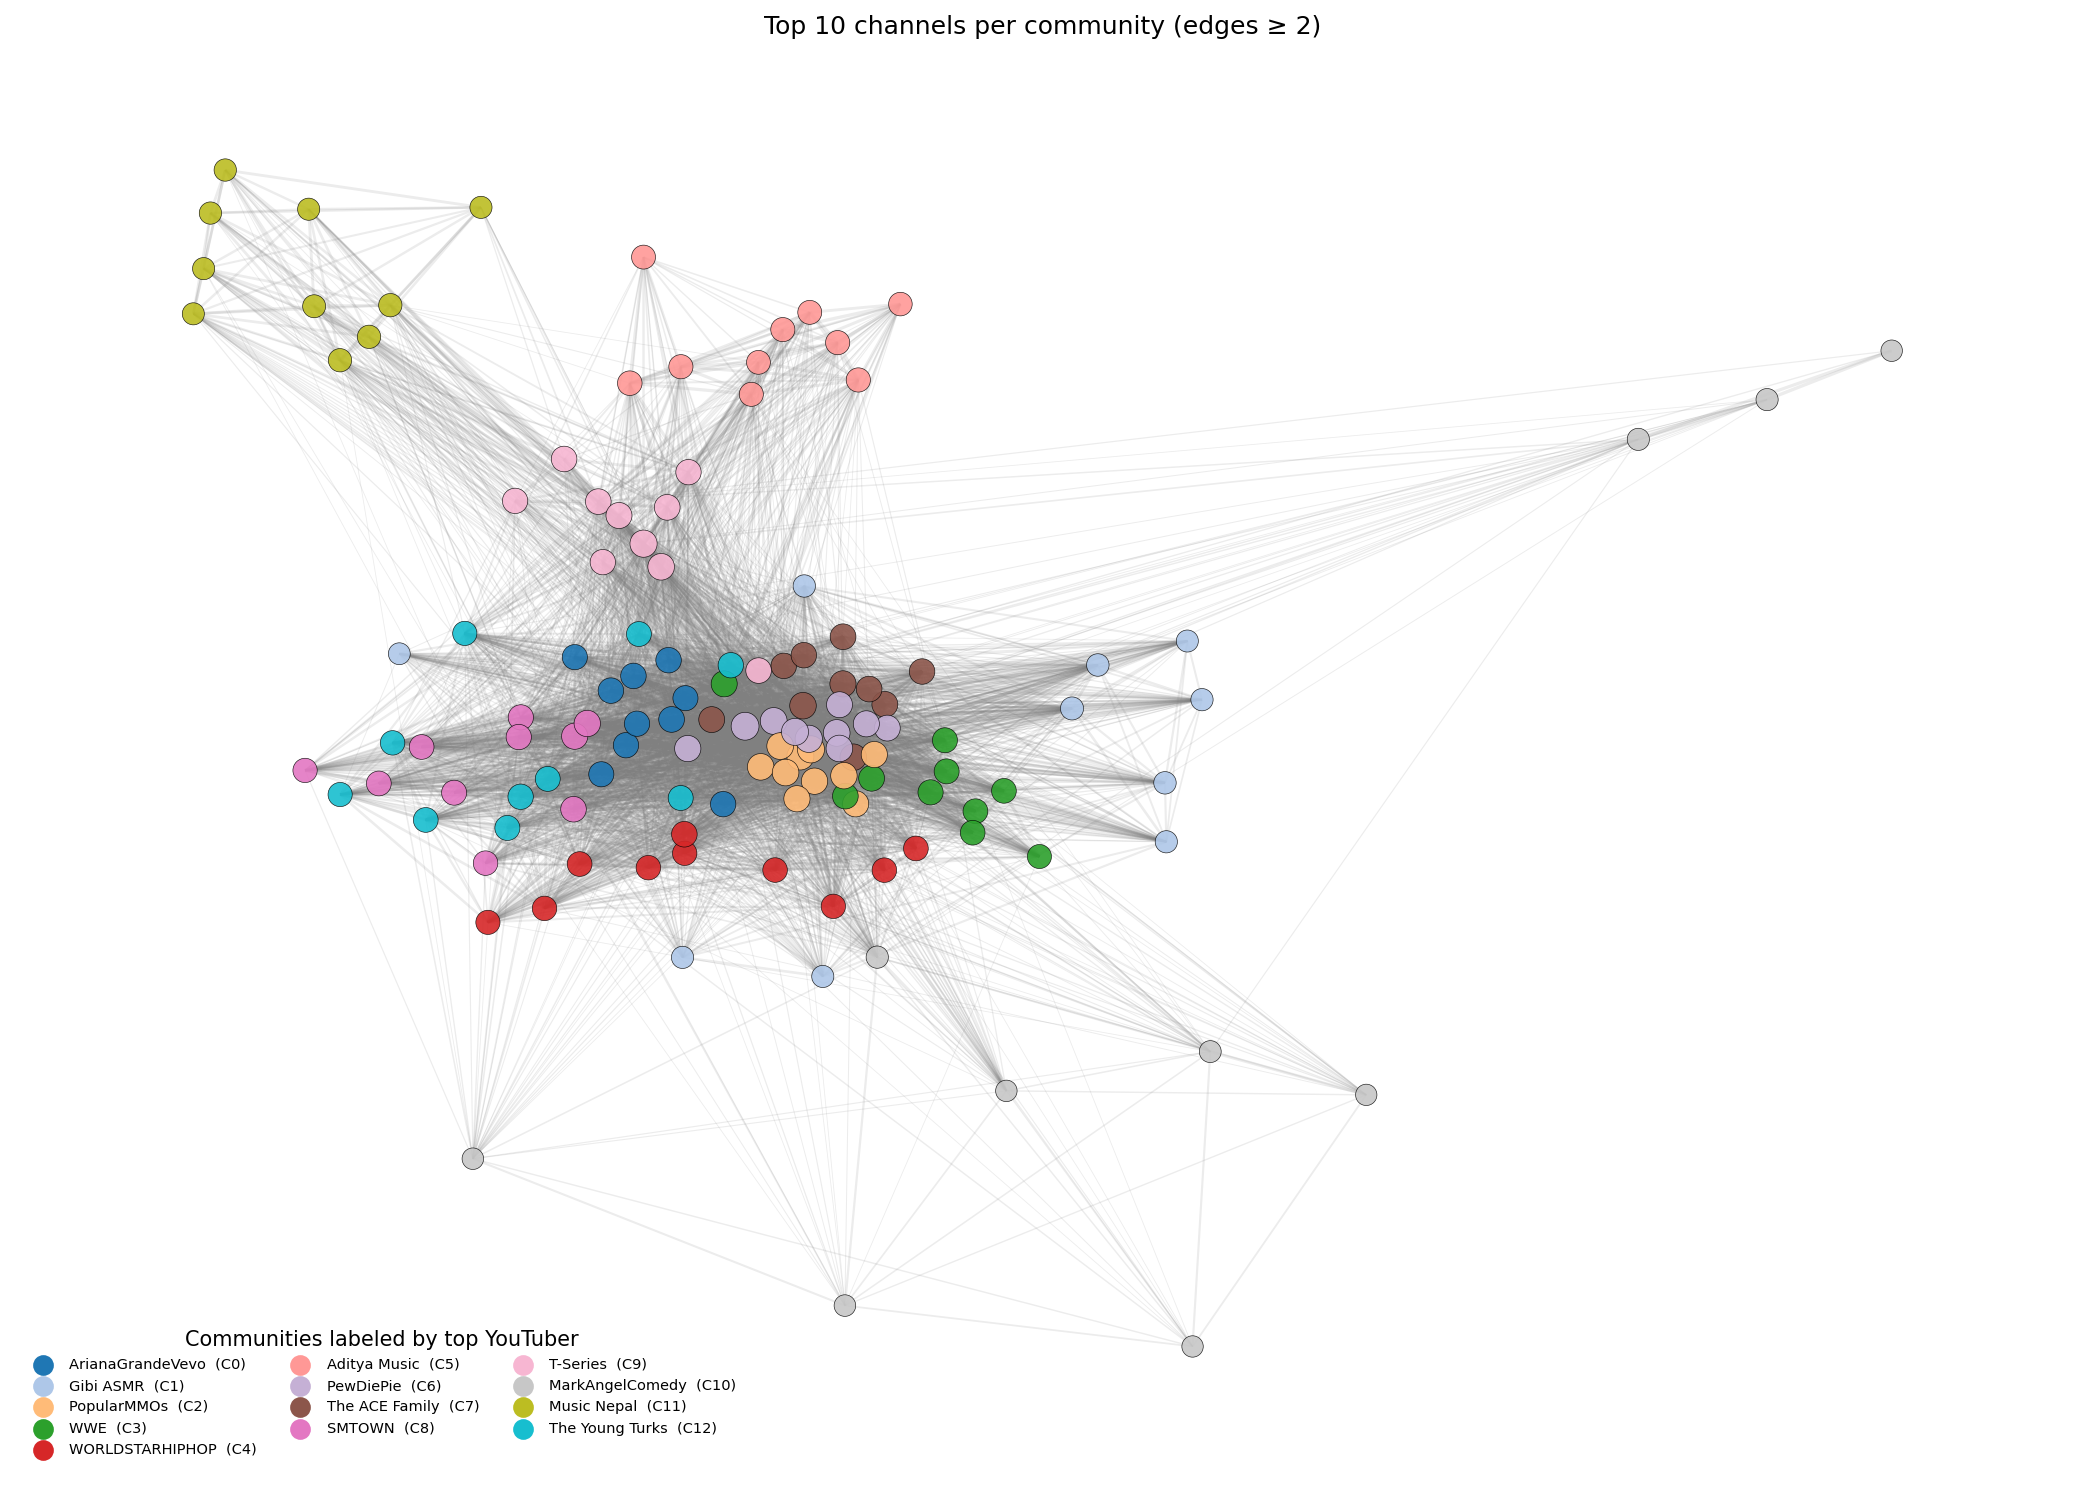

In [9]:
model_analyzer.visualize_network(
    LCC, 
    communities, 
    node_df, 
    viz_out_path=VIZ_OUT_PATH
)

## 6. Topic Detection for Communities

Now we apply topic detection to identify the themes within each community. This uses LDA (Latent Dirichlet Allocation) following the methodology from Lab 9.

In [10]:
# Install required packages if not already installed
!pip install spacy gensim
!python -m spacy download en_core_web_sm

import spacy

# Load spacy model
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print("✓ Spacy model loaded")
except:
    print("⚠️  Run: python -m spacy download en_core_web_sm")
    nlp = None


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 13.3 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✓ Spacy model loaded


### Load video metadata for topic detection

In [11]:
# Load video metadata for topic detection
# Stream directly from the YouNiverse dataset zip file
# Only loads videos from channels in our communities (efficient)

# Sort communities by size (largest first) for better analysis
communities_sorted = sorted(communities, key=len, reverse=True)
print("Top 10 communities by size:")
for i, comm in enumerate(communities_sorted[:10]):
    print(f"  Community {i}: {len(comm):,} channels")

# Collect channel IDs from the LARGEST communities
n_communities_to_analyze = 5
all_channels = set()
for i in range(min(n_communities_to_analyze, len(communities_sorted))):
    all_channels.update(communities_sorted[i])

print(f"\nNeed videos from {len(all_channels)} unique channels across {n_communities_to_analyze} largest communities")

# Stream videos from the zip file (no extraction needed)
video_df = data_loader.stream_video_metadata_from_zip(
    zip_path='data/youniverse-dataset.zip',
    channel_filter=all_channels,
    max_videos_per_channel=100  # Adjust as needed (50=fast, 200=more data)
)

if len(video_df) == 0:
    print("\nError: No videos loaded. Check that data/youniverse-dataset.zip exists.")
else:
    print(f"\n✓ Successfully loaded {len(video_df):,} videos")
    print(f"  Columns: {list(video_df.columns)}")
    print(f"  Ready for topic detection!")

Top 10 communities by size:
  Community 0: 4,216 channels
  Community 1: 3,919 channels
  Community 2: 3,505 channels
  Community 3: 3,448 channels
  Community 4: 3,264 channels
  Community 5: 2,349 channels
  Community 6: 1,510 channels
  Community 7: 871 channels
  Community 8: 478 channels
  Community 9: 399 channels

Need videos from 18352 unique channels across 5 largest communities
Streaming video metadata from data/youniverse-dataset.zip...
Filtering for 18352 channels...
Reading yt_metadata_en.jsonl.gz from zip...
  Processed 49,000,000 records, kept 1,090,320...
  Processed 62,000,000 records, kept 1,380,172...

Loaded 1,623,274 videos from 18352 channels
Processed 72,924,794 total records

✓ Successfully loaded 1,623,274 videos
  Columns: ['channel_id', 'title', 'description', 'tags']
  Ready for topic detection!


### Analyze topics for each community

In [12]:
# Analyze top communities
# Reload module to ensure latest code is used
import importlib
importlib.reload(model_analyzer)

n_communities_to_analyze = 5
community_topics = {}

# Verify video_df has the right columns
print(f"Video DataFrame columns: {list(video_df.columns)}")
print(f"Video DataFrame shape: {video_df.shape}")

# Use communities_sorted (sorted by size, largest first)
for i, community in enumerate(communities_sorted[:n_communities_to_analyze]):
    print(f"\n{'='*80}")
    print(f"COMMUNITY {i} (size: {len(community)} channels)")
    print(f"{'='*80}\n")
    
    result = model_analyzer.categoryDetect(
        community=community,
        video_metadata_df=video_df,
        k_channels=10,              # Sample 10 channels
        n_videos_per_channel=50,    # Up to 50 videos per channel
        n_topics=4,                 # Extract 4 topics
        text_mode='combined',       # Use title + tags + truncated desc (TA recommended)
        desc_max_chars=200,         # Truncate descriptions to 200 chars
        min_wordcount=5,
        max_freq=0.5,
        passes=10,
        seed=42,
        nlp=nlp
    )
    
    community_topics[i] = result
    print("\n")

Video DataFrame columns: ['channel_id', 'title', 'description', 'tags']
Video DataFrame shape: (1623274, 4)

COMMUNITY 0 (size: 4216 channels)

=== Topic Detection for Community (4216 channels) ===
Sampled 10 channels from community
Sampled 500 videos
Using combined mode: title + tags + description (truncated to 200 chars)
Processing 500 texts with spacy...
Preprocessed 500 documents
Adding bigrams...
Creating dictionary and corpus...
Number of unique tokens: 769
Number of documents: 500
Training LDA model with 4 topics...

Detected 4 topics:

Topic 0: mehndi, marathi, Marathi, goshti, design
Topic 1: food, challenge, eat, street, street_food
Topic 2: comedy, video, jitu, mangu, komal
Topic 3: hindi, pubg, rhyme, free, Hindi



COMMUNITY 1 (size: 3919 channels)

=== Topic Detection for Community (3919 channels) ===
Sampled 10 channels from community
Sampled 466 videos
Using combined mode: title + tags + description (truncated to 200 chars)
Processing 466 texts with spacy...
Preprocesse

### Compare detected topics with official YouTube categories

In [13]:
# Compare detected topics with official categories
for comm_id in range(min(3, len(communities_sorted))):
    community = communities_sorted[comm_id]
    
    # Get official categories from node_df
    comm_nodes = node_df[node_df['channel_id'].isin(community)]
    categories = comm_nodes['category_cc'].value_counts()
    
    print(f"\n{'='*80}")
    print(f"Community {comm_id}")
    print(f"{'='*80}")
    
    print(f"\nOfficial YouTube Category Distribution:")
    for cat, count in categories.head(5).items():
        pct = count / len(community) * 100
        print(f"  {cat:20s} {count:4d} channels ({pct:5.1f}%)")
    
    if comm_id in community_topics and community_topics[comm_id]['topics']:
        print(f"\nDetected Topics (LDA):")
        for topic_id, topic_words in enumerate(community_topics[comm_id]['topics']):
            words = ', '.join([word for word, _ in topic_words[:5]])
            print(f"  Topic {topic_id + 1}: {words}")
    
    print()


Community 0

Official YouTube Category Distribution:
  Entertainment         978 channels ( 23.2%)
  Music                 573 channels ( 13.6%)
  Howto & Style         542 channels ( 12.9%)
  Education             508 channels ( 12.0%)
  People & Blogs        409 channels (  9.7%)

Detected Topics (LDA):
  Topic 1: mehndi, marathi, Marathi, goshti, design
  Topic 2: food, challenge, eat, street, street_food
  Topic 3: comedy, video, jitu, mangu, komal
  Topic 4: hindi, pubg, rhyme, free, Hindi


Community 1

Official YouTube Category Distribution:
  Music                2443 channels ( 62.3%)
  Entertainment         606 channels ( 15.5%)
  People & Blogs        173 channels (  4.4%)
  Film and Animation    140 channels (  3.6%)
  Gaming                125 channels (  3.2%)

Detected Topics (LDA):
  Topic 1: rikodisco, follow, video, parkour, house
  Topic 2: Andrea, Bocelli, Andrea_Bocelli, bocelli, andrea
  Topic 3: aoki, steve_aoki, steve, Aoki, Radio
  Topic 4: Billy, Corgan, Smas

### Optional: Visualize topics with pyLDAvis

In [14]:
# Display topics nicely for each community
def display_topics(community_topics):
    for comm_id, result in community_topics.items():
        print(f"\n{'='*60}")
        print(f"COMMUNITY {comm_id} - Detected Topics")
        print(f"{'='*60}")
        print(f"Videos analyzed: {result.get('n_videos', 0)}")
        print(f"Channels sampled: {len(result.get('sampled_channels', []))}")
        
        topics = result.get('topics', [])
        if not topics:
            print("No topics detected")
            continue
            
        for topic_id, topic_words in enumerate(topics):
            print(f"\n  Topic {topic_id + 1}:")
            top_words = [f"{word} ({weight:.2f})" for word, weight in topic_words[:5]]
            print(f"    {', '.join(top_words)}")

display_topics(community_topics)


COMMUNITY 0 - Detected Topics
Videos analyzed: 500
Channels sampled: 10

  Topic 1:
    mehndi (0.08), marathi (0.07), Marathi (0.04), goshti (0.04), design (0.03)

  Topic 2:
    food (0.12), challenge (0.11), eat (0.07), street (0.05), street_food (0.04)

  Topic 3:
    comedy (0.04), video (0.04), jitu (0.04), mangu (0.03), komal (0.03)

  Topic 4:
    hindi (0.08), pubg (0.06), rhyme (0.05), free (0.04), Hindi (0.03)

COMMUNITY 1 - Detected Topics
Videos analyzed: 466
Channels sampled: 10

  Topic 1:
    rikodisco (0.04), follow (0.03), video (0.02), parkour (0.02), house (0.02)

  Topic 2:
    Andrea (0.06), Bocelli (0.06), Andrea_Bocelli (0.05), bocelli (0.04), andrea (0.03)

  Topic 3:
    aoki (0.04), steve_aoki (0.03), steve (0.03), Aoki (0.03), Radio (0.02)

  Topic 4:
    Billy (0.05), Corgan (0.05), Smashing (0.04), Billy_Corgan (0.03), Pumpkins (0.03)

COMMUNITY 2 - Detected Topics
Videos analyzed: 409
Channels sampled: 10

  Topic 1:
    jungle (0.05), league (0.04), gam

### Interactive Topic Visualization with pyLDAvis

In [15]:
# Install pyLDAvis if needed (uncomment and run once)
# !pip install pyldavis

import warnings
warnings.filterwarnings('ignore')  # Suppress multiprocessing warnings

import pyLDAvis
import pyLDAvis.gensim_models

# Enable notebook visualization
pyLDAvis.enable_notebook()

# Visualize topics for a specific community
comm_id = 0  # Change this to visualize different communities (0, 1, 2, ...)

if comm_id in community_topics:
    result = community_topics[comm_id]
    if result.get('model') and result.get('corpus') and result.get('dictionary'):
        print(f"Preparing visualization for Community {comm_id}...")
        
        # Prepare the visualization data
        vis_data = pyLDAvis.gensim_models.prepare(
            result['model'], 
            result['corpus'], 
            result['dictionary'],
            sort_topics=False
        )
        
        # Save to HTML file (always works)
        html_path = f'reports/figures/lda_community_{comm_id}.html'
        pyLDAvis.save_html(vis_data, html_path)
        print(f"✓ Saved interactive visualization to: {html_path}")
        print(f"  Open this file in your browser to see the visualization!")
        
        # Try to display inline (may not work in all environments)
        try:
            pyLDAvis.display(vis_data)
        except Exception as e:
            print(f"\\n(Inline display not available: {e})")
            print("Use the HTML file instead.")
    else:
        print(f"Community {comm_id} missing model/corpus/dictionary")
else:
    print(f"Community {comm_id} not found in results")

Preparing visualization for Community 0...


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=40719) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=40719) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=40719) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=40719) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarnin

✓ Saved interactive visualization to: reports/figures/lda_community_0.html
  Open this file in your browser to see the visualization!


### Save topic detection results

In [ ]:
# Create summary DataFrame
summary_data = []

for comm_id, result in community_topics.items():
    if result['topics']:
        # Get top 5 words from each topic
        topic_summaries = []
        for topic_words in result['topics']:
            top_words = ', '.join([word for word, _ in topic_words[:5]])
            topic_summaries.append(top_words)
        
        summary_data.append({
            'community_id': comm_id,
            'n_channels': len(communities_sorted[comm_id]),
            'n_videos_analyzed': result['n_videos'],
            'n_topics': len(result['topics']),
            'topics': ' | '.join(topic_summaries)
        })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('data/processed/community_topics_summary.csv', index=False)

print("✓ Results saved to data/processed/community_topics_summary.csv\n")
summary_df

✓ Results saved to data/processed/community_topics_summary.csv



,community_id,n_channels,n_videos_analyzed,n_topics,topics
0,0,4216,500,4,"mehndi, marathi, Marathi, goshti, design | foo..."
1,1,3919,466,4,"rikodisco, follow, video, parkour, house | And..."
2,2,3505,409,4,"jungle, league, gameplay, season, legend | Pok..."
3,3,3448,414,4,"robux, meme, free, free_robux, compilation | M..."
4,4,3264,500,4,"challenge, food, home, eat, burger | finger, A..."


Exception ignored in: <function ResourceTracker.__del__ at 0x107322480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110a26480>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107526480>
Traceback (most recent call last